# K-means Clustering

For starters, let’s break down what K-means clustering means:

*    **Clustering**: the model groups data points into different clusters 

*   **K**: K is a variable that we set; it represents how many clusters we want our model to create  
*   **Means**: each cluster has a mean, and each data point will be assigned to the cluster whose mean is closest to the given data point

Let’s look at an example. We have the following data points that we’d like to group into three groups (K = 3):




Here’s how our K-means clustering model goes about it.

First, it randomly selects three data points (I’ve marked them with different colors):

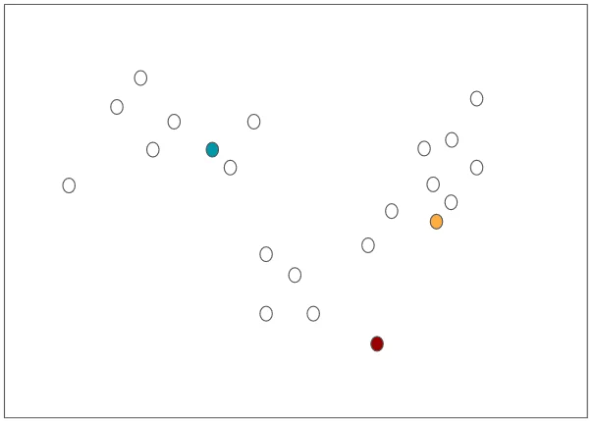

These points are called cluster centroids because they mark the center of the clusters.

Our model then measures – using Euclidean distance – the distance of each data point to the cluster centroids, and assigns each data point to the cluster whose centroid is closest to the data point:

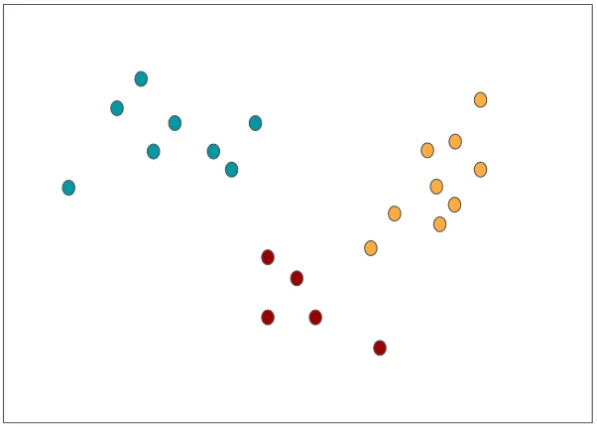


Now that we have three groups, each group’s cluster centroid gets recalculated (=will move to a new position) based on the average of the data points within the group, then the data points get assigned again to the closest cluster centroid (marked with a cross). Notice how data points can switch teams:

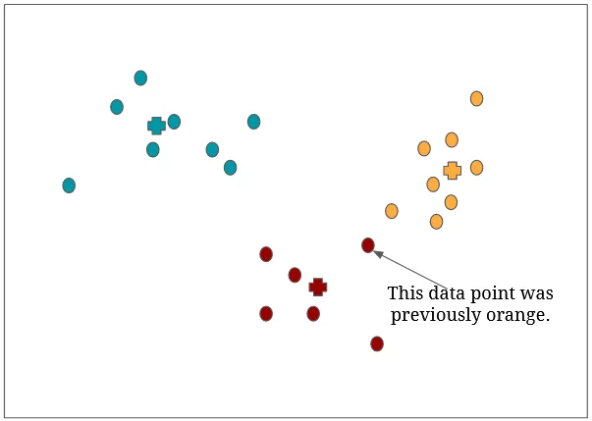

The algorithm repeats the above steps until the data points stop switching groups (=each data point is assigned to its final group, no more team switching for them).

And that’s it. 🙂

I believe two questions arise at this point:

Is that all? Answer: yep.
How do we know what value to choose for K? Answer: you’ll find it out in the coding section. 😉

# EXAMPLE

#### Imagine we have 19 data points that look like this:

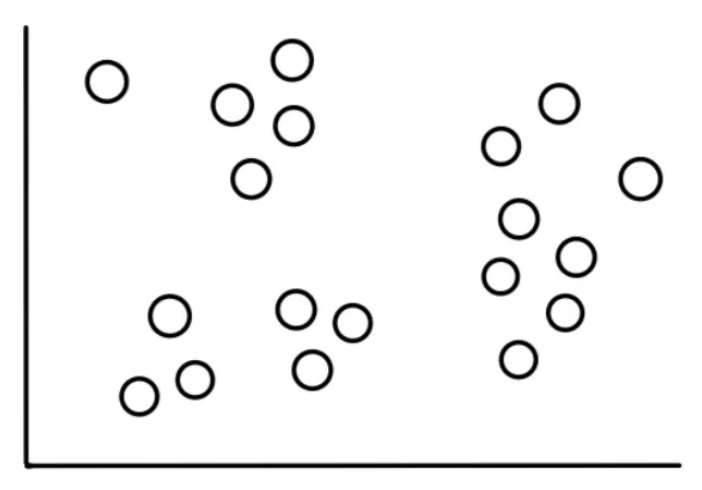





#### Now assume that we know this data fits into 3, relatively obvious, categories that look like this:

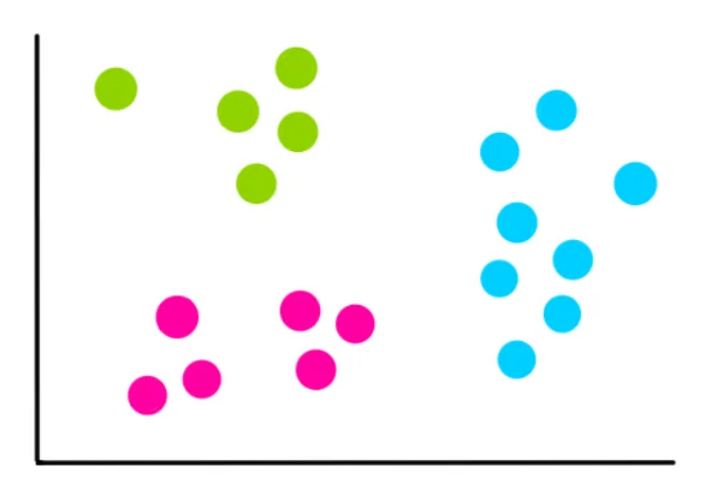

Our task is to use the k-means Clustering algorithm to do this categorization.


### Step 1: Select the Number of Clusters, k
The number of clusters we want to identify is the k in k-means clustering. In this case, since we assumed that there are 3 clusters, k = 3.

### Step 2: Select k Points at Random
We start the process of finding clusters by selecting 3 random points (not necessarily our data points). These points will now act as centroids, or the center, of clusters that we are going to make:

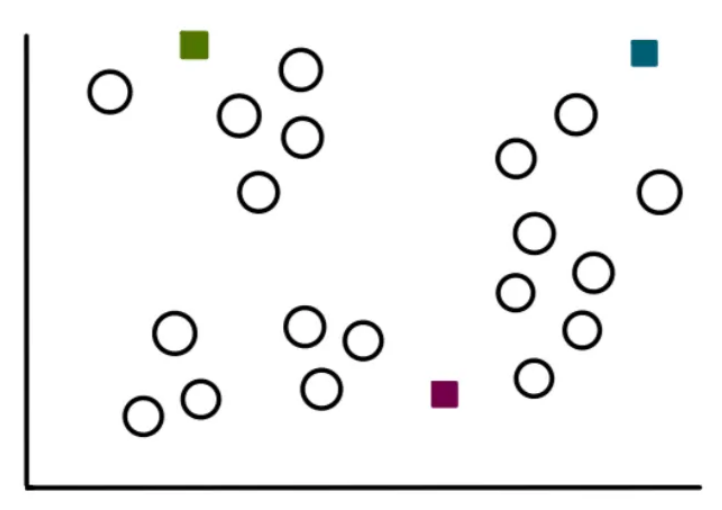



### Step 3: Make k Clusters
To make the clusters, we start by measuring the distance from each data point to each of the 3 centroids. And we assign the points to the cluster closest to it. So for a sample point, the distances will look like this:

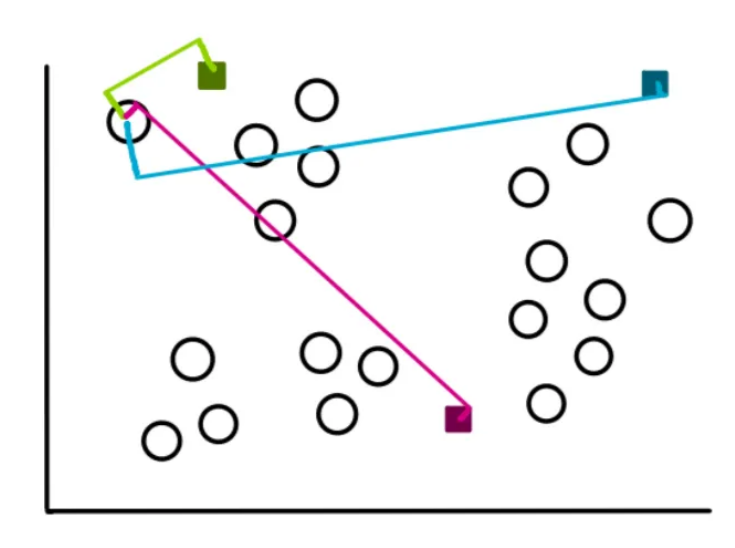

By just looking at it, we see that the distance from the point to the green centroid is the least, so we assign the point to the green cluster.

In two dimensions, the formula to find the distance between two points is:

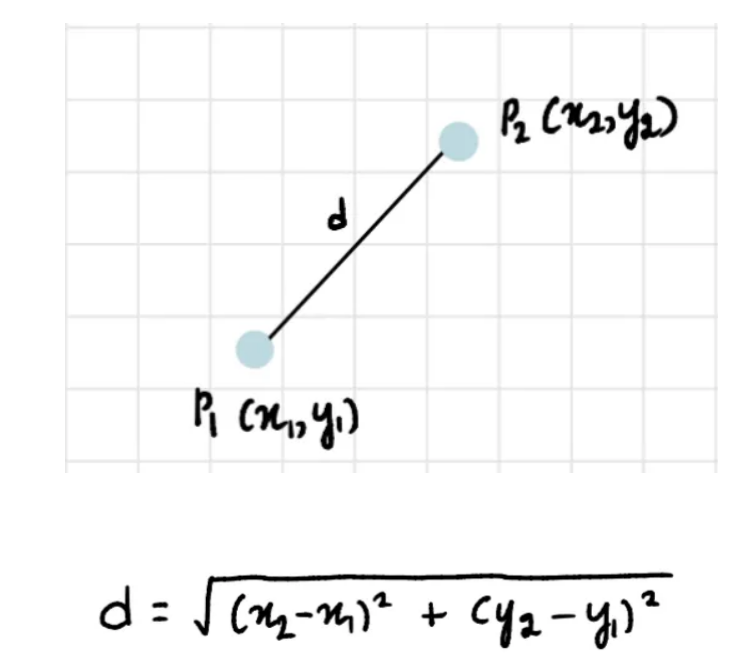

Using the above formula, we repeat this process for the rest of the points and the clusters will look something like this:

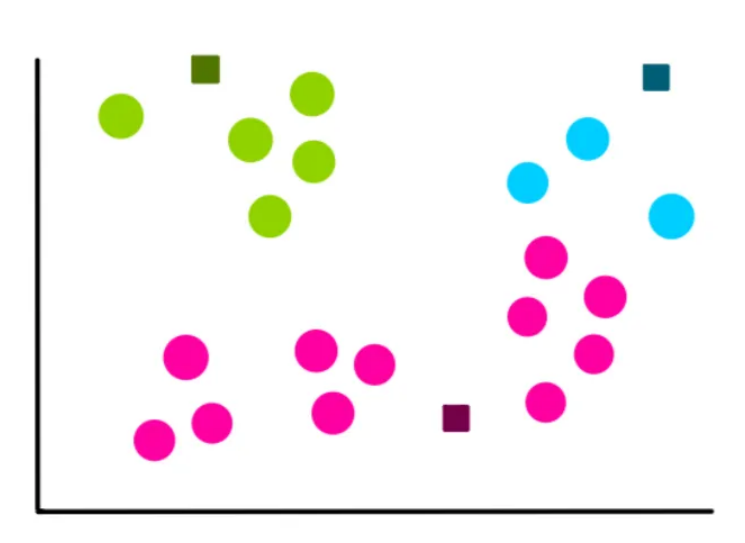

### Step 4: Compute New Centroid of Each Cluster
Now that we have our 3 clusters, we find the new centroids formed by each of them. For instance, the way we calculate the coordinates of the centroid of the blue cluster is:

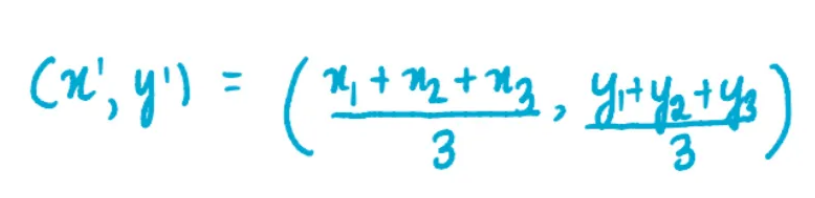

where x1, x2, and x3 are the x-coordinates of each of the 3 points of the blue cluster. And y1, y2, and y3 are the y-coordinates of each of the 3 points of the blue cluster. We divide the sum of the coordinates by 3 because there are 3 data points in the blue cluster. Similarly, the coordinates of the centroids of the pink and green clusters are:


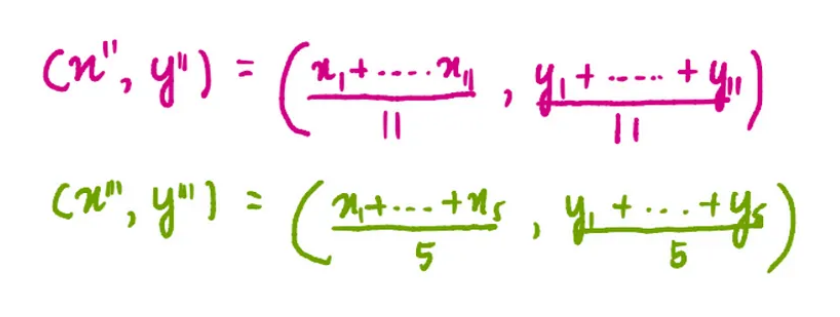

So, the new centroids look like this:

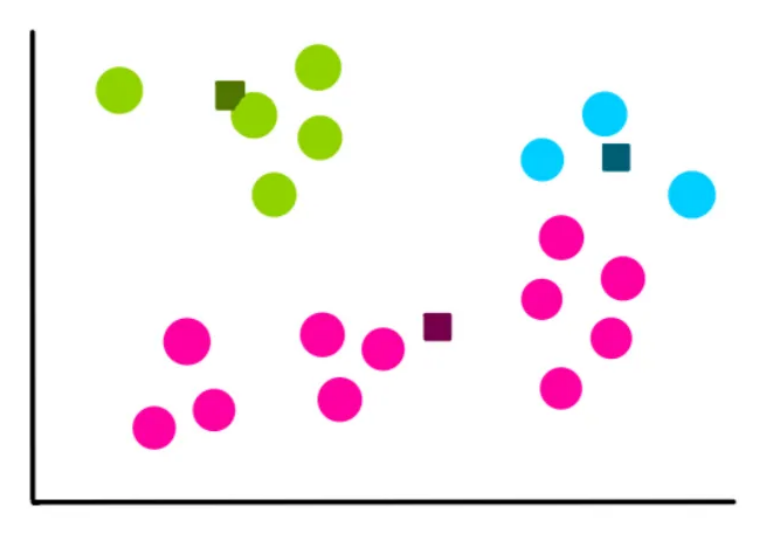



### Step 5: Assess the Quality of Each Cluster
Since k-means can’t see the clustering as we can, it measures the quality by finding the variation within all the clusters. The basic idea behind k-means clustering is defining clusters so that the within-cluster variation is minimized. We calculate something called Within-Cluster Sum of Squares (WCSS) to quantify this variance:

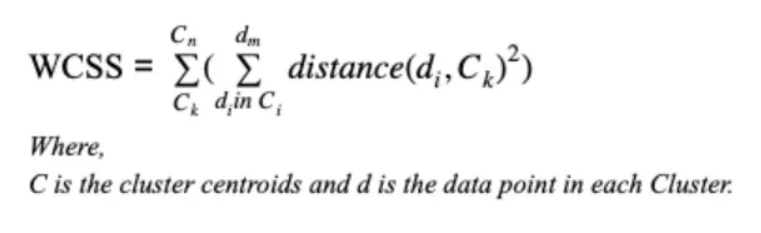

This is a scary-looking formula, so if you don't really understand it that’s okay; just try to understand the intuition behind it.

For simplification purposes, let’s represent the variation visually like this:

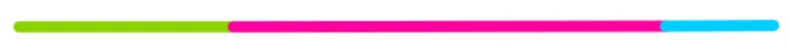

### Step 6: Repeat Steps 3–5
Once we have previous clusters and the variation stored, we start all over. But only this time we use the centroids we calculated previously to - make 3 new clusters, recalculate the center of the new clusters, and calculate the sum of the variation within all the clusters.

Let’s suppose the next 4 iterations look like this:

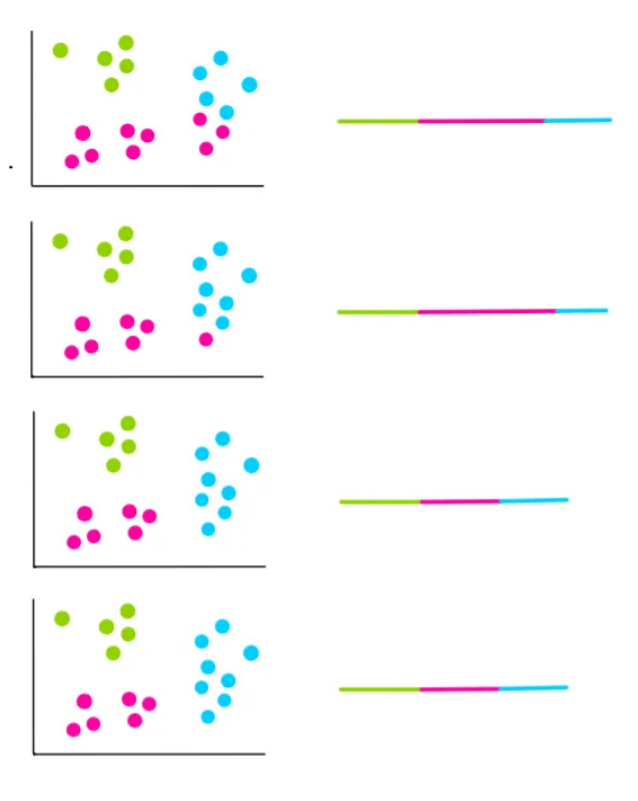

From the last two iterations, we see that the clusters haven’t changed. This means that the algorithm has converged and we stop the clustering process. We then choose the clusters with the least WCSS. This also happens to be those of the last two iterations. So, they are going to be our final clusters.

### How do we choose k?
In our example, we conveniently knew that we need 3 clusters. But what if we don't know how many clusters we have, then how do we choose k?

In this case, we try multiple k values and calculate the WCSS.

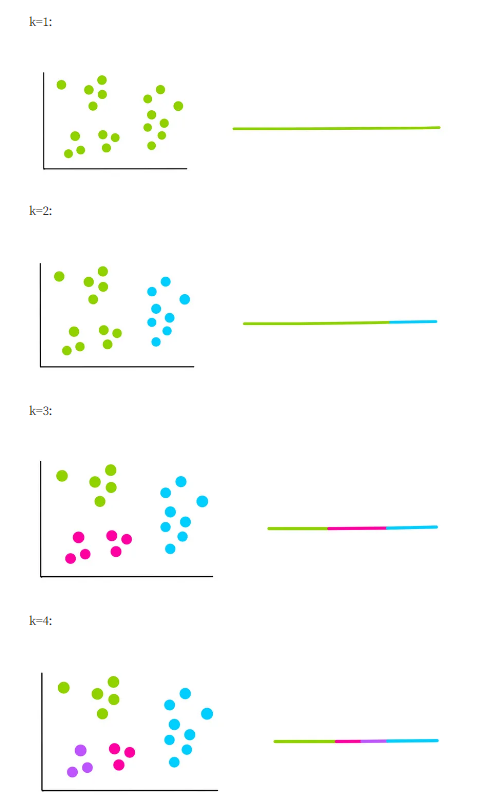

We notice that each time we add a new cluster, the total variation within each cluster is smaller than before. And when there is only one point per cluster, the variation = 0.

#### NB: Measures of variation are statistics of how far away the values in the observations (data points) are from each other.

So, we need to use something called an elbow plot to find the best k. It plots the WCSS against the number of clusters or k.

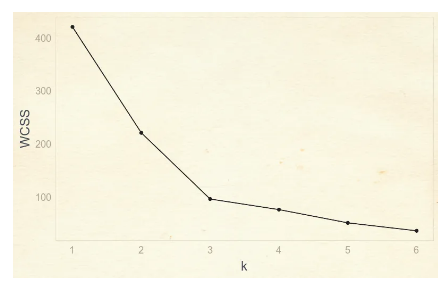

This is called an elbow plot because we can find an optimal k value by finding the “elbow” of the plot, which is at 3. Until 3 you can notice a huge reduction in variation, but after that, the variation doesn't go down as quickly.

And that’s about it. A simple, but effective clustering algorithm!

# How can you code a K-means clustering model in python

1.   #### Dropping unnecessary rows/columns before clustering

We’ll work with a dataset from Kaggle.

https://www.kaggle.com/datasets/vetrirah/customer

The dataset contains customer data, like gender, age, profession, size of family, etc. Our plan is to create clusters out of these customers.

Read in the dataset, save it to df, and view five random rows of it with the sample method:


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#df = pd.read_csv("https://raw.githubusercontent.com/leenaali1114/Data-Science-Datasets/main/Customer_data.csv", on_bad_lines='skip')
df = pd.read_csv("https://raw.githubusercontent.com/leenaali1114/Data-Science-Datasets/main/Customer_data.csv")

In [3]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


As the Segmentation column suggests, the customers have been already segmented by a certain logic (if you read the dataset’s description, you’ll know the full story). Since we want to create our own clusters, let’s remove this column along with ID

In [56]:
df = df.drop(["Segmentation", "ID"], axis='columns')

In [57]:
df = df.drop(["Var_1"], axis='columns')

In [58]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,Male,No,22,No,Healthcare,1.0,Low,4.0
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0


It’s always recommended to get a general sense of the dataset you’re working with, so let’s do just that with df.info():

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   object 
 1   Ever_Married     7928 non-null   object 
 2   Age              8068 non-null   int64  
 3   Graduated        7990 non-null   object 
 4   Profession       7944 non-null   object 
 5   Work_Experience  7239 non-null   float64
 6   Spending_Score   8068 non-null   object 
 7   Family_Size      7733 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 504.4+ KB


In [60]:
df.isna().sum()

Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
dtype: int64

According to the RangeIndex part, our dataframe (df) holds 8,068 rows. By looking at the number of data points in each column, we can establish that we have many missing data points (e.g. Graduated has 7,990 rows instead of 8,068).

For the sake of simplicity, we remove all rows with any missing values with df.dropna():

In [61]:
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6718 entries, 0 to 8067
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           6718 non-null   object 
 1   Ever_Married     6718 non-null   object 
 2   Age              6718 non-null   int64  
 3   Graduated        6718 non-null   object 
 4   Profession       6718 non-null   object 
 5   Work_Experience  6718 non-null   float64
 6   Spending_Score   6718 non-null   object 
 7   Family_Size      6718 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 472.4+ KB


df.info() now shows that all columns have 6,718 rows, but our index still goes from 0 to 8067, so we reset it with df.reset_index(), then remove the freshly created index column with df.drop("index", axis="columns"):

In [62]:
df = df.reset_index()
df.head()

,index,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,0,Male,No,22,No,Healthcare,1.0,Low,4.0
1,2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0
2,3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0
3,5,Male,Yes,56,No,Artist,0.0,Average,2.0
4,6,Male,No,32,Yes,Healthcare,1.0,Low,3.0


In [63]:
df = df.drop(["index"], axis="columns")
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,Male,No,22,No,Healthcare,1.0,Low,4.0
1,Female,Yes,67,Yes,Engineer,1.0,Low,1.0
2,Male,Yes,67,Yes,Lawyer,0.0,High,2.0
3,Male,Yes,56,No,Artist,0.0,Average,2.0
4,Male,No,32,Yes,Healthcare,1.0,Low,3.0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6718 entries, 0 to 6717
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           6718 non-null   object 
 1   Ever_Married     6718 non-null   object 
 2   Age              6718 non-null   int64  
 3   Graduated        6718 non-null   object 
 4   Profession       6718 non-null   object 
 5   Work_Experience  6718 non-null   float64
 6   Spending_Score   6718 non-null   object 
 7   Family_Size      6718 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 420.0+ KB


To create a K-means clustering model, it’d be perfectly fine if you just removed the Segmentation and the ID columns, and the rows with missing values.

In [65]:
cols = ['Gender','Ever_Married','Graduated','Profession','Spending_Score']

In [66]:

# Import label encoder 
from sklearn.preprocessing import LabelEncoder 
  
# label_encoder object knows  
# how to understand word labels. 
label_encoder = LabelEncoder() 
  
# Encode labels in column 'Gender'. 
# df['Gender']= label_encoder.fit_transform(df['Gender']) 


df[cols] = df[cols].apply(LabelEncoder().fit_transform)

In [67]:
df

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,1,0,22,0,5,1.0,2,4.0
1,0,1,67,1,2,1.0,2,1.0
2,1,1,67,1,7,0.0,1,2.0
3,1,1,56,0,0,0.0,0,2.0
4,1,0,32,1,5,1.0,2,3.0
...,...,...,...,...,...,...,...,...
6713,1,1,41,1,0,0.0,1,5.0
6714,1,0,35,0,4,3.0,2,4.0
6715,0,0,33,1,5,1.0,2,1.0
6716,0,0,27,1,5,1.0,2,4.0



#### 4. Creating the K-means clustering model
Finally, we can create our K-means clustering model:

In [68]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=4)
clusters = kmeans_model.fit_predict(df)
# df.insert(df.columns.get_loc("Family_Size"), "Cluster", clusters)
df.insert(8,"Cluster",clusters,True)

df.head(25)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Cluster
0,1,0,22,0,5,1.0,2,4.0,0
1,0,1,67,1,2,1.0,2,1.0,1
2,1,1,67,1,7,0.0,1,2.0,1
3,1,1,56,0,0,0.0,0,2.0,2
4,1,0,32,1,5,1.0,2,3.0,0
5,0,0,33,1,5,1.0,2,3.0,0
6,0,1,61,1,2,0.0,2,3.0,2
7,0,1,55,1,0,1.0,0,4.0,2
8,0,0,26,1,2,1.0,2,3.0,0
9,1,0,19,0,5,4.0,2,4.0,0


In [35]:
df = df.drop(['Cluster'], axis = "columns")

In [36]:

print(clusters)


[3 3 3 ... 0 0 0]


* **from sklearn.cluster import KMeans** imports the K-means clustering algorithm,
* **KMeans(n_clusters=3)** saves the algorithm into kmeans_model, where n_clusters denotes the number of clusters we’d like to create,
* **kmeans_model.fit_predict(df)** clusters our customers into one of the three clusters, and then the cluster labels are saved to clusters,
* **df.insert(df_kmeans.columns.get_loc("Age"), "Cluster", clusters)** creates a new column (Cluster) holding the previously created clusters’ values (aka what cluster our model assigned to each customer in our dataset); df.columns.get_loc("Age") is responsible for inserting Cluster as the first column.
If you’re curious, df.Cluster.unique() will show you the labels for the clusters:

In [38]:
df.Cluster.unique()

AttributeError: 'DataFrame' object has no attribute 'Cluster'

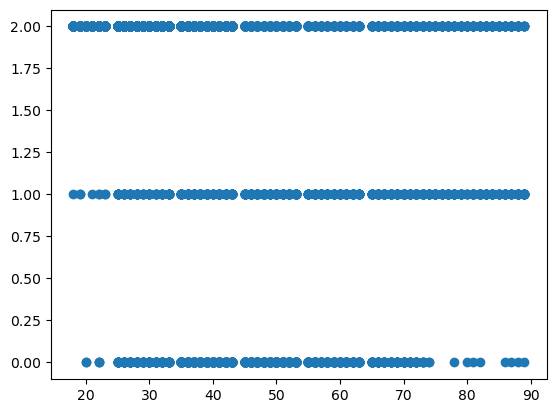

In [39]:
#plotting the results
plt.scatter(df['Age'] , df['Spending_Score'])
plt.show()

And that’s how you create a K-means clustering model. 🙂

# Finding the ideal number of clusters with the elbow method

The so-called elbow method is a common way to find the ideal number of clusters within a dataset.

It’s called elbow, because:

* it takes the possible values of K that you choose,
** for example, beginning from two clusters and going up to eight clusters the values for K would be: 2, 3, 4, 5, 6, 7, 8,
* calculates the **sum of squared distances (SSD for short)** for every value of K (=number of clusters),
**SSD is the result of calculating in each cluster, how far the data points are from the cluster centroid, then adding up the results for all clusters**; think of it as something that shows the variance of your data (fun fact: as the number of clusters increase, the SSD decreases),
* creates a line plot where the x-axis contains the values that K can take on, and the y-axis shows the SSD (=variance) for each K (=number of clusters).
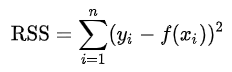




Once the above steps have been carried out, our task is to identify the elbow point (=the number for K), after which there are no more sudden drops in the line plot (=SSD is not significantly reduced, so there’s no need to add more clusters).

You’ll immediately get what I’m talking about by looking at this chart:

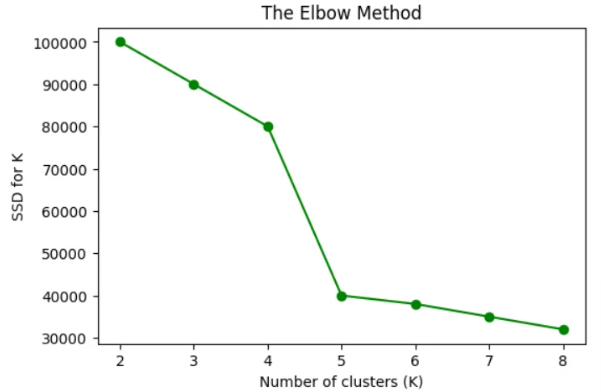

The solution here is five; after it, there seem to be no more sudden drops, so the ideal number for this dataset would be five.

We’ll apply the elbow method to our dataset with the below code:

In [40]:
wcss = {'wcss_score':[], 'no_of_clusters':[]}
for i in range(1,11):
    kmeans = KMeans(i, random_state=0)
    kmeans.fit(df)
    k = float(kmeans.inertia_)
#     print(k)
    wcss['wcss_score'].append(k)
    wcss['no_of_clusters'].append(i)
    print(wcss)
wcss_df = pd.DataFrame(wcss)

wcss_df.head(10)

{'wcss_score': [24674807854.876514], 'no_of_clusters': [1]}
{'wcss_score': [24674807854.876514, 6170191167.455807], 'no_of_clusters': [1, 2]}
{'wcss_score': [24674807854.876514, 6170191167.455807, 2743422585.144035], 'no_of_clusters': [1, 2, 3]}
{'wcss_score': [24674807854.876514, 6170191167.455807, 2743422585.144035, 1544085675.5628557], 'no_of_clusters': [1, 2, 3, 4]}
{'wcss_score': [24674807854.876514, 6170191167.455807, 2743422585.144035, 1544085675.5628557, 988932074.2580338], 'no_of_clusters': [1, 2, 3, 4, 5]}
{'wcss_score': [24674807854.876514, 6170191167.455807, 2743422585.144035, 1544085675.5628557, 988932074.2580338, 687878894.3263392], 'no_of_clusters': [1, 2, 3, 4, 5, 6]}
{'wcss_score': [24674807854.876514, 6170191167.455807, 2743422585.144035, 1544085675.5628557, 988932074.2580338, 687878894.3263392, 505706886.957142], 'no_of_clusters': [1, 2, 3, 4, 5, 6, 7]}
{'wcss_score': [24674807854.876514, 6170191167.455807, 2743422585.144035, 1544085675.5628557, 988932074.2580338, 68

,wcss_score,no_of_clusters
0,2.467481e+10,1
1,6.170191e+09,2
2,2.743423e+09,3
3,1.544086e+09,4
4,9.889321e+08,5
5,6.878789e+08,6
6,5.057069e+08,7
7,3.875776e+08,8
8,3.068483e+08,9
9,2.490193e+08,10


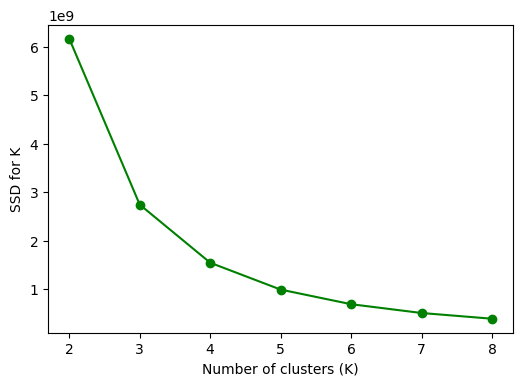

In [41]:
ssd = []
for k in range(2, 9):
    kmeans_model = KMeans(n_clusters=k)
    kmeans_model.fit(df)
    ssd.append(kmeans_model.inertia_)
plt.figure(figsize=(6, 4), dpi=100)
plt.plot(range(2, 9), ssd, color="green", marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSD for K")
plt.show()

In [43]:
df

,level_0,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,0,1,0,22,0,5,1.0,2,4.0
1,1,0,1,67,1,2,1.0,2,1.0
2,2,1,1,67,1,7,0.0,1,2.0
3,3,1,1,56,0,0,0.0,0,2.0
4,4,1,0,32,1,5,1.0,2,3.0
...,...,...,...,...,...,...,...,...,...
6660,6660,1,1,41,1,0,0.0,1,5.0
6661,6661,1,0,35,0,4,3.0,2,4.0
6662,6662,0,0,33,1,5,1.0,2,1.0
6663,6663,0,0,27,1,5,1.0,2,4.0


Here’s the breakdown of the code:

* ssd is a list of the calculated SSD values for each value of K,
* we set a minimum and a maximum value for K with range(2, 9), and loop through them (for k in range(2, 9)),
* at each loop, we create a K-means clustering model for k (kmeans_model = KMeans(n_clusters=k)),
* then we fit the model (kmeans_model.fit(df_kmeans)),
* and add its calculated SSD (ssd.append(kmeans_model.inertia_)) to ssd,
note: inertia means SSD,
* and finally, we visualize it with the rest of the code.

I’d say that the ideal number of clusters for this dataset is four instead of three. So we can rerun the code with K being equal to four, but I won’t do that now, because there’s still one important aspect that we need to touch on.

What if we don’t see an elbow in the chart? 🤔

Yes, it can happen. It’s not guaranteed that you’ll always get an elbow.

Why?

Because life isn’t always sunshine and puppies, and data science is hard.

But we’re tough, ain’t we? 😎

Whenever you encounter such difficulties, start googling. You’ll be encouraged by seeing others having the same problems – like here, here, or here.

The thing is, there’s always a solution. If you don’t see an elbow point, the solution could be to look at the silhouette score.



In [69]:
from sklearn.metrics import silhouette_score
score = silhouette_score(df, df.Cluster, random_state=0)
print(f"Silhouette score: {score:0.3f} ~ 0")

Silhouette score: 0.418 ~ 0


### Silhouette Coefficient:
Silhouette Coefficient or silhouette score is a metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1.

#### 1: Means clusters are well apart from each other and clearly distinguished.

#### 0: Means clusters are indifferent, or we can say that the distance between clusters is not significant.

#### -1: Means clusters are assigned in the wrong way.

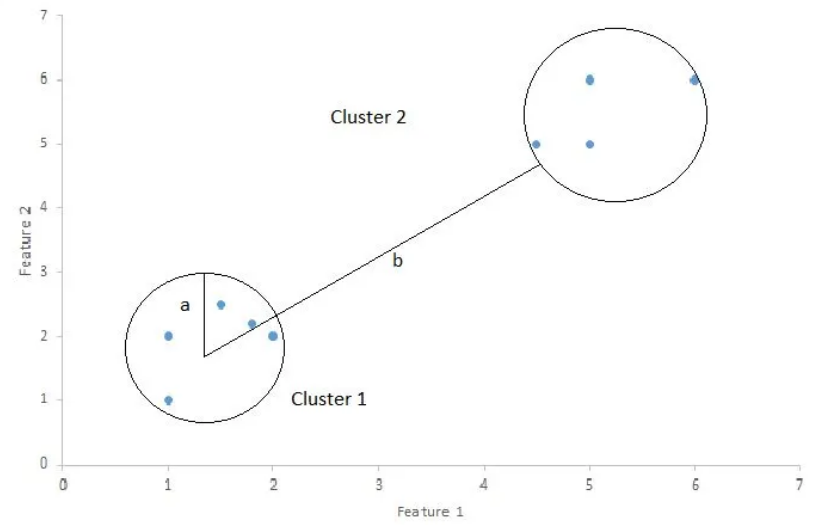


##### Silhouette Score = (b-a)/max(a,b)

where

a= average intra-cluster distance i.e the average distance between each point within a cluster.

b= average inter-cluster distance i.e the average distance between all clusters.

# K-means from scratch

In [70]:
#import libraries
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt

In [71]:
data = pd.read_csv('clustering.csv')
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'clustering.csv'

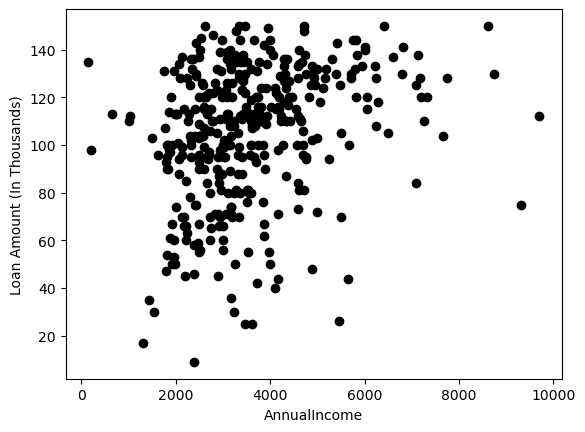

In [4]:
X = data[["LoanAmount","ApplicantIncome"]]
#Visualise data points
plt.scatter(X["ApplicantIncome"],X["LoanAmount"],c='black')
plt.xlabel('AnnualIncome')
plt.ylabel('Loan Amount (In Thousands)')
plt.show()

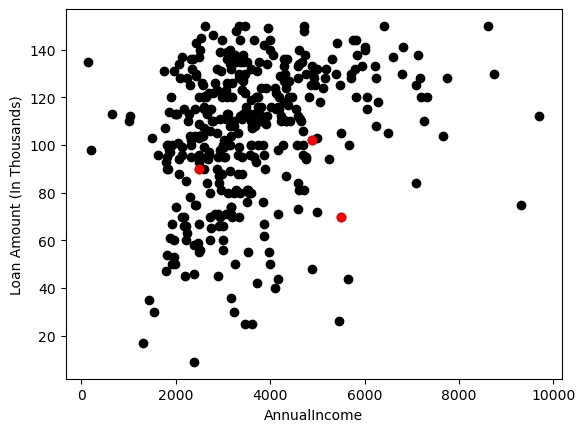

In [8]:
# Step 1 and 2 - Choose the number of clusters (k) and select random centroid for each cluster

#number of clusters
K=3

# Select random observation as centroids
Centroids = (X.sample(n=K))
plt.scatter(X["ApplicantIncome"],X["LoanAmount"],c='black')
plt.scatter(Centroids["ApplicantIncome"],Centroids["LoanAmount"],c='red')
plt.xlabel('AnnualIncome')
plt.ylabel('Loan Amount (In Thousands)')
plt.show()

In [6]:
# Step 3 - Assign all the points to the closest cluster centroid
# Step 4 - Recompute centroids of newly formed clusters
# Step 5 - Repeat step 3 and 4

diff = 1
j=0

while(diff!=0):
    XD=X
    i=1
    for index1,row_c in Centroids.iterrows():
        ED=[]
        for index2,row_d in XD.iterrows():
            d1=(row_c["ApplicantIncome"]-row_d["ApplicantIncome"])**2
            d2=(row_c["LoanAmount"]-row_d["LoanAmount"])**2
            d=np.sqrt(d1+d2)
            ED.append(d)
        X[i]=ED
        i=i+1

    C=[]
    for index,row in X.iterrows():
        min_dist=row[1]
        pos=1
        for i in range(K):
            if row[i+1] < min_dist:
                min_dist = row[i+1]
                pos=i+1
        C.append(pos)
    X["Cluster"]=C
    Centroids_new = X.groupby(["Cluster"]).mean()[["LoanAmount","ApplicantIncome"]]
    if j == 0:
        diff=1
        j=j+1
    else:
        diff = (Centroids_new['LoanAmount'] - Centroids['LoanAmount']).sum() + (Centroids_new['ApplicantIncome'] - Centroids['ApplicantIncome']).sum()
        print(diff.sum())
    Centroids = X.groupby(["Cluster"]).mean()[["LoanAmount","ApplicantIncome"]]


C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i]=ED
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i]=ED
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

294.98852727378676
216.30028144385471
169.46106058187374


C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"]=C
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i]=ED
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

198.9136595178422
52.84741626127729


C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i]=ED
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"]=C
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

98.54724443834282
90.64953219227577
18.274686272279013


C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"]=C
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i]=ED
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

9.21023994083339
18.345487493007468


C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"]=C
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[i]=ED
C:\Users\hp\AppData\Local\Temp\ipykernel_3708\2856282022.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

46.27013250786139
0.0


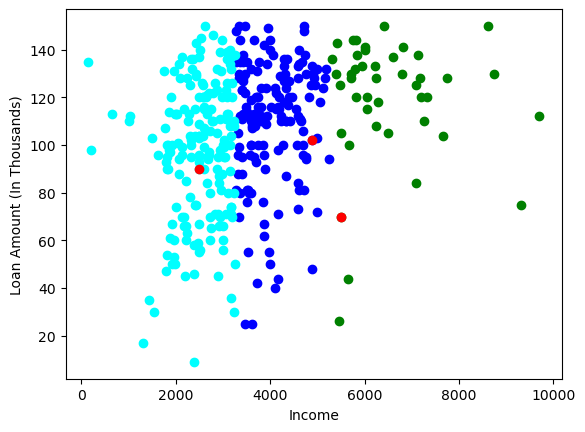

In [9]:
color=['blue','green','cyan']
for k in range(K):
    data=X[X["Cluster"]==k+1]
    plt.scatter(data["ApplicantIncome"],data["LoanAmount"],c=color[k])
plt.scatter(Centroids["ApplicantIncome"],Centroids["LoanAmount"],c='red')
plt.xlabel('Income')
plt.ylabel('Loan Amount (In Thousands)')
plt.show()